# PERSIST Gene selection - GSE139088

**Aim:** Create a Gene list for spatial transcriptomics

The gene list is created in a three-step approach:

1. A list of manually curated genes and genes on interest.
2. Using the *supervised* PERSIST method with the cell annotation. This step is to include genes for more rare cell populations such as DCs etc that might be missed if only and unsupervised approach is used.
3. In a third step, we will increase the gene list using the *unsupervised* PERSIST method to select genes that are maximally predictive of the genome-wide expression profile.

A GPU is extremely helpful, as Pytorch runs a LOT faster with it.

In [1]:
from pathlib import Path
import sys
import scanpy as sc
import scipy
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import torch
from persist import PERSIST, ExpressionDataset, HurdleLoss
import sklearn.model_selection
import session_info
import warnings
warnings.filterwarnings('ignore')


# Decrease this for testing, default 250
MAX_NEPOCHS = 250

/home/workspace/environment/sc-persist/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import the reference dataset

The datasets will be used to train the panel

* GSE139088 <- current script
* GSE254789

In [2]:
base_dir = Path('/home/workspace/private/projects/kim/drg')
panel_dir = base_dir / 'panel/gene-lists'

adata_path = base_dir / 'data/scrna-seq/h5ad/04_clustered/GSE139088-scvi-leiden.h5ad'

kim_path = panel_dir / 'input/zhen-gene-list.csv'
flow_path = panel_dir / 'input/flow-panel-genes.csv'

output_dir = panel_dir / 'output'
os.makedirs(output_dir, exist_ok = True)

In [3]:
def import_drg() -> sc.AnnData:
    """
    Import the Mouse drg reference dataset and perform some initial preprocessing steps.

    Returns:
        AnnData object representing the preprocessed mouse drg Cell Reference dataset.
    """
    adata = sc.read_h5ad(adata_path)
    adata.layers['log1p'] = adata.X.copy()
    sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=10000, inplace=True)
    adata.obs['codes'] = pd.Categorical(adata.obs['original_annotation']).codes
    adata.var["features"] = adata.var.index
    adata.var_names = adata.var["features"]
    return adata
adata = import_drg()
adata

AnnData object with n_obs × n_vars = 10729 × 20924
    obs: 'original_annotation', 'GSE', 'GSM', 'sample_number', 'sample_id', 'experiment_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'doublet_scores', 'predicted_doublets', '_scvi_batch', '_scvi_labels', 'leiden', 'codes'
    var: 'mt', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'features'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'original_annotation_colors', 'rank_genes_groups', 'sample_id_colors', 'umap', 'hvg'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts', 'log1p', 'normalized_1e6'
    obsp: 'connectivities', 'distances'

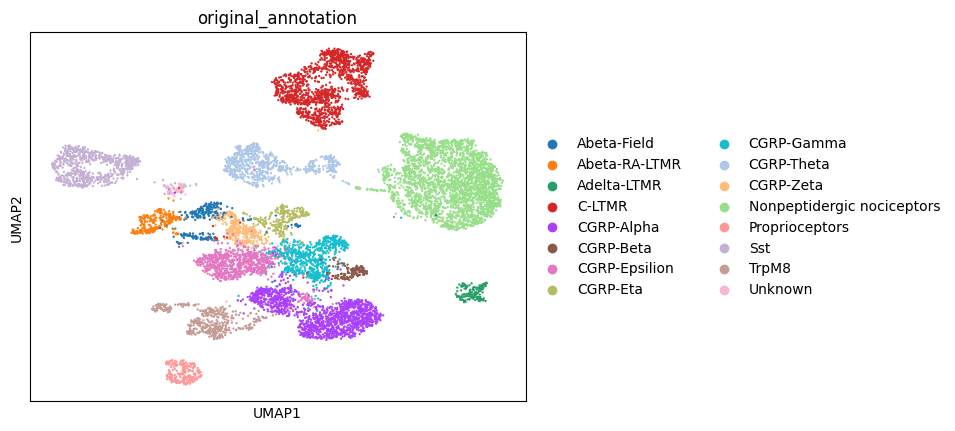

In [4]:
sc.pl.umap(adata, color="original_annotation")

## Manual gene selection

These are the manually selected genes, that will be included in the final gene panel. PERSIST will choose the best genes to complement this manual selection.

### Helper functions

In [5]:
def all_genes_in_panel(panel: dict) -> list:
    """
    Returns a set of unique genes from the given panel.
    
    Args:
        panel (dict): A dictionary representing a genomic panel, where keys are sample names and values are lists of gene names for each sample.
    
    Returns:
        set: A set of unique genes found in the given panel.
    """
    return list(set(sum(panel.values(), [])))

def print_panel(panel: dict):
    """
    Prints information about the given panel, including the number of unique genes and a list of genes for each sample.
    
    Args:
        panel (dict): A dictionary representing a genomic panel, where keys are sample names and values are lists of gene names for each sample.
    
    Returns:
        None
    """
    class color:
        PURPLE = '\033[95m'
        CYAN = '\033[96m'
        DARKCYAN = '\033[36m'
        BLUE = '\033[94m'
        GREEN = '\033[92m'
        YELLOW = '\033[93m'
        RED = '\033[91m'
        BOLD = '\033[1m'
        UNDERLINE = '\033[4m'
        END = '\033[0m'

    print(color.UNDERLINE + color.BOLD + "Current Panel" + color.END)
    print(f"currently {color.PURPLE}{len(all_genes_in_panel(panel))}{color.END} unique genes")
    for k in panel.keys():
        import textwrap
        genes = ', '.join(panel[k])
        genes = '\n'.join(textwrap.wrap(genes, 128))
        print(color.BOLD + k + color.END + f" ({len(panel[k])} genes): " + genes)


### Gene lists

In [6]:
# Flow cytometry panel
#artis_480 = pd.read_csv(os.path.join(panel_dir, "existing-panels/ID/TV46KD.csv")) #Artis panel
#artis_480 = artis_480['Gene'].unique()
#artis_480 = list(artis_480)
#print("artis panel:", len(artis_480), "genes")

# Kim lab gene list
kim_list = pd.read_csv(kim_path)
kim_list = kim_list['gene'].unique()
kim_list = list(kim_list)
print("Kim list length:", len(kim_list), "genes")

# Spectral flow panel genes
flow_list = pd.read_csv(flow_path)
flow_list = flow_list['gene'].unique()
flow_list = list(flow_list)
print("Spectral flow panel list length:", len(flow_list), "genes")

Kim list length: 115 genes
Spectral flow panel list length: 51 genes


### Putting it together

In [7]:
panel = {
    "zhen_list": kim_list,
    "spectral_panel": flow_list,
    "GSE139088_supervised": [],
    "GSE139088_unsupervised": [],
}
print_panel(panel)

Current Panel
currently 165 unique genes
zhen_list (115 genes): Nppb, Sst, Cysltr1, Cysltr2, Il31ra, Il4ra, Il13ra1, Il13ra2, Osmr, Jak1, Stat6, Piezo2, Adra2a, Bmpr1b, Nefh, Th, Ret, Cd274,
Pdcd1, Kit, Ntrk1, Ntrk2, Ntrk3, Scn8a, Scn9a, Scn10a, Scn11a, Tac1, Calca, Calcb, Nmb, Nts, Adcyap1, Mrgprd, Mrgpra1, Mrgpra3,
Mrgprc11, Mrgprb4, Trpa1, Trpv1, Trpv2, Trpv4, Trpm3, Trpm5, Trpm8, Oprk1, Oprd1, Oprm1, Asic1, Asic2, Asic3, Asic4, P2ry1,
P2ry2, P2ry4, P2rx2, P2rx3, P2rx4, Gfra1, Gfra2, Gfra3, Sstr1, Sstr2, Sstr3, Sstr4, Sstr5, Hrh1, Hrh2, Hrh3, Hrh4, Htr1a, Htr1b,
Htr1d, Htr1f, Htr2a, Htr2b, Htr2c, Htr3a, Htr3b, Htr4, Htr5a, Htr5b, Htr5c, Htr6, Htr7, F2r, F2rl1, F2rl2, F2rl3, S1pr1, S1pr2,
S1pr3, S1pr4, S1pr5, Ptger1, Ptger2, Ptger3, Ptger4, Tnfrsf1a, Il1r1, Il6st, Il17ra, Il10rb, Tlr4, Tlr5, Tlr7, Crlf2, Cbln2,
Ldhb, Necab2, Fam19a1, Smr2, Hpse, Spp1, Ntm
spectral_panel (51 genes): Ptprc, Cd8a, Cd44, Thy1, Cd4, Pdcd1, Cd8b1, Ifng, Havcr2, Gzmb, Tnf, Il17a, Prf1, Il2, H2-D1, Foxp3, Ro

In [8]:
def are_genes_in_adata(adata, panel: dict):
    """
    Checks if all genes in a panel are present in anndata.

    Parameters:
        adata (anndata.AnnData): The annotated data.
        panel (list or str): The list of gene names or a single string representing the gene name.

    Returns:
        None
    """

    # Let's see if all genes are in the anndata, and if not which are missing
    genes = all_genes_in_panel(panel)
    for gene in genes:
        if gene not in adata.var_names.values:
            print(gene, "not found")

print("drg")
are_genes_in_adata(adata, panel)


drg
Cd8a not found
Htr5c not found
Cd19 not found
Pdcd1 not found
Il17a not found
Cxcr3 not found
Hrh4 not found
Tigit not found
Cxcr6 not found
Prf1 not found
Ifng not found
Mrgprc11 not found
Ctla4 not found


## Supervised gene selection

In [9]:
def supervised_selection(adata, var_name: str, panel, codes: str, add: int, target=150, lam_init=None):  # target should be ~2x the number of genes that we want to add
    adata = adata.copy()
    genes = all_genes_in_panel(panel)
    print(f"{len(genes)} are currently in the panel. Will add {add} new genes.")
    adata.var["markers"] = adata.var[var_name].isin(all_genes_in_panel(panel))
    print(f"{np.sum(adata.var['markers'])} genes have been found in the adata object")

    # restrict to 10k highly variable genes
    adata = adata[:, (adata.var["highly_variable"] | adata.var["markers"])]

    # save binarized data in a separate layer
    adata.layers["bin"] = (adata.X > 0).astype(np.float32)

    # Convert string labels to integer codes
    if not pd.api.types.is_numeric_dtype(adata.obs[codes]):
        encoded_col = f"{codes}_codes"
        adata.obs[encoded_col] = pd.Categorical(adata.obs[codes]).codes
        codes = encoded_col

    # Run PERSIST according to the documentation.
    train_ind, val_ind = sk.model_selection.train_test_split(
        np.arange(adata.shape[0]), train_size=0.8, random_state=0
    )

    print(f"{adata.shape[0]} total samples")
    print(f"{np.size(train_ind)} in training set")
    print(f"{np.size(val_ind)} in validation set")

    # These are views, so they do not take up memory
    adata_train = adata[train_ind, :]
    adata_val = adata[val_ind, :]

    # Initialize the dataset for PERSIST
    train_dataset = ExpressionDataset(
        adata_train.layers["bin"].toarray(), adata_train.obs[codes]
    )
    val_dataset = ExpressionDataset(
        adata_val.layers["bin"].toarray(), adata_val.obs[codes]
    )

    # Use GPU device if available -- we highly recommend using a GPU!
    device = torch.device(
        torch.cuda.current_device() if torch.cuda.is_available() else "cpu"
    )
    print("Using device:", device)

    # Number of genes to select within the current selection process.
    preselected_inds = list(np.where(adata.var["markers"])[0])

    # Set up the PERSIST selector
    selector = PERSIST(
        train_dataset,
        val_dataset,
        loss_fn=torch.nn.CrossEntropyLoss(),
        device=device,
        preselected_inds=preselected_inds,
    )

    # Coarse removal of genes
    print("Starting initial elimination...")
    candidates, model = selector.eliminate(
        target=target, max_nepochs=MAX_NEPOCHS,
        lam_init=lam_init
    )  # target should be ~2x the number of genes that we want to add
    print("Completed initial elimination.")

    print("Selecting specific number of genes...")
    inds, model = selector.select(num_genes=add, max_nepochs=MAX_NEPOCHS)
    new_genes = list(adata.var[var_name][inds])
    print(f"Selected {add} new genes: {new_genes}")
    print("Done")
    return new_genes

### run supervised drg

In [10]:
panel["GSE139088_supervised"] = supervised_selection(
    adata=adata, var_name="features", panel=panel, codes="codes", add=50
)

165 are currently in the panel. Will add 50 new genes.
152 genes have been found in the adata object
10729 total samples
8583 in training set
2146 in validation set
Using device: cuda:0
Starting initial elimination...
using CrossEntropyLoss, starting with lam = 0.0001


Training epochs: 100%|██████████| 250/250 [05:34<00:00,  1.34s/it]


lam = 0.000100 yielded 54 genes
Reinitializing model for next iteration
next attempt is lam = 0.000036


Training epochs: 100%|██████████| 250/250 [05:37<00:00,  1.35s/it]


lam = 0.000036 yielded 162 genes
done, lam = 0.000036 yielded 162 genes
Completed initial elimination.
Selecting specific number of genes...


Training epochs: 100%|██████████| 250/250 [04:11<00:00,  1.00s/it]

done, selected 50 genes
Selected 50 new genes: ['1500009L16Rik', 'Adgrg2', 'Atp1b1', 'Bex1', 'Cartpt', 'Cdhr1', 'Chd5', 'Chrna3', 'Col25a1', 'Crip1', 'Ctcflos', 'Ctxn2', 'Dcn', 'Etv1', 'Gda', 'Gm765', 'Hapln1', 'Islr2', 'Kcnk3', 'Kcnmb1', 'Kcnq3', 'Lcorl', 'Ldlrad3', 'Lef1', 'Litaf', 'Lmo1', 'Mef2c', 'Mgat5b', 'Mrap2', 'Ndst4', 'Ntng1', 'Opcml', 'Pcdh10', 'Pfkfb3', 'Pkib', 'Plekha2', 'Prkcb', 'Prokr2', 'Ptprt', 'Rasgrp1', 'Resp18', 'Rgs5', 'RP23-291B1.2', 'Rph3a', 'Rprm', 'S100a16', 'Steap3', 'Tagln2', 'Unc5c', 'Vamp1']
Done


In [11]:
print_panel(panel)

Current Panel
currently 215 unique genes
zhen_list (115 genes): Nppb, Sst, Cysltr1, Cysltr2, Il31ra, Il4ra, Il13ra1, Il13ra2, Osmr, Jak1, Stat6, Piezo2, Adra2a, Bmpr1b, Nefh, Th, Ret, Cd274,
Pdcd1, Kit, Ntrk1, Ntrk2, Ntrk3, Scn8a, Scn9a, Scn10a, Scn11a, Tac1, Calca, Calcb, Nmb, Nts, Adcyap1, Mrgprd, Mrgpra1, Mrgpra3,
Mrgprc11, Mrgprb4, Trpa1, Trpv1, Trpv2, Trpv4, Trpm3, Trpm5, Trpm8, Oprk1, Oprd1, Oprm1, Asic1, Asic2, Asic3, Asic4, P2ry1,
P2ry2, P2ry4, P2rx2, P2rx3, P2rx4, Gfra1, Gfra2, Gfra3, Sstr1, Sstr2, Sstr3, Sstr4, Sstr5, Hrh1, Hrh2, Hrh3, Hrh4, Htr1a, Htr1b,
Htr1d, Htr1f, Htr2a, Htr2b, Htr2c, Htr3a, Htr3b, Htr4, Htr5a, Htr5b, Htr5c, Htr6, Htr7, F2r, F2rl1, F2rl2, F2rl3, S1pr1, S1pr2,
S1pr3, S1pr4, S1pr5, Ptger1, Ptger2, Ptger3, Ptger4, Tnfrsf1a, Il1r1, Il6st, Il17ra, Il10rb, Tlr4, Tlr5, Tlr7, Crlf2, Cbln2,
Ldhb, Necab2, Fam19a1, Smr2, Hpse, Spp1, Ntm
spectral_panel (51 genes): Ptprc, Cd8a, Cd44, Thy1, Cd4, Pdcd1, Cd8b1, Ifng, Havcr2, Gzmb, Tnf, Il17a, Prf1, Il2, H2-D1, Foxp3, Ro

### Save supervised list

In [15]:
import os
supervised_list = panel["GSE139088_supervised"]
df = pd.DataFrame(supervised_list, columns=["gene"])
df.to_csv(os.path.join(output_dir, "GSE139088_supervised.csv"), index=False)

print("Saved GSE139088_supervised.csv")

Saved GSE139088_supervised.csv


# Checkpoint due to memory issue

In [16]:
from pathlib import Path
import sys
import scanpy as sc
import scipy
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import torch
from persist import PERSIST, ExpressionDataset, HurdleLoss
import sklearn.model_selection
import session_info
import warnings
warnings.filterwarnings('ignore')


# Decrease this for testing, default 250
MAX_NEPOCHS = 250

In [17]:
base_dir = Path('/home/workspace/private/projects/kim/drg')
panel_dir = base_dir / 'panel/gene-lists'

adata_path = base_dir / 'data/scrna-seq/h5ad/04_clustered/GSE139088-scvi-leiden.h5ad'

kim_path = panel_dir / 'input/zhen-gene-list.csv'
flow_path = panel_dir / 'input/flow-panel-genes.csv'

output_dir = panel_dir / 'output'

In [18]:
def import_drg() -> sc.AnnData:
    """
    Import the Mouse drg reference dataset and perform some initial preprocessing steps.

    Returns:
        AnnData object representing the preprocessed mouse drg Cell Reference dataset.
    """
    adata = sc.read_h5ad(adata_path)
    adata.layers['log1p'] = adata.X.copy()
    sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=10000, inplace=True)
    adata.obs['codes'] = pd.Categorical(adata.obs['original_annotation']).codes
    adata.var["features"] = adata.var.index
    adata.var_names = adata.var["features"]
    return adata
adata = import_drg()
adata

AnnData object with n_obs × n_vars = 10729 × 20924
    obs: 'original_annotation', 'GSE', 'GSM', 'sample_number', 'sample_id', 'experiment_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'doublet_scores', 'predicted_doublets', '_scvi_batch', '_scvi_labels', 'leiden', 'codes'
    var: 'mt', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'features'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'original_annotation_colors', 'rank_genes_groups', 'sample_id_colors', 'umap', 'hvg'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts', 'log1p', 'normalized_1e6'
    obsp: 'connectivities', 'distances'

In [19]:
def all_genes_in_panel(panel: dict) -> list:
    """
    Returns a set of unique genes from the given panel.
    
    Args:
        panel (dict): A dictionary representing a genomic panel, where keys are sample names and values are lists of gene names for each sample.
    
    Returns:
        set: A set of unique genes found in the given panel.
    """
    return list(set(sum(panel.values(), [])))

def print_panel(panel: dict):
    """
    Prints information about the given panel, including the number of unique genes and a list of genes for each sample.
    
    Args:
        panel (dict): A dictionary representing a genomic panel, where keys are sample names and values are lists of gene names for each sample.
    
    Returns:
        None
    """
    class color:
        PURPLE = '\033[95m'
        CYAN = '\033[96m'
        DARKCYAN = '\033[36m'
        BLUE = '\033[94m'
        GREEN = '\033[92m'
        YELLOW = '\033[93m'
        RED = '\033[91m'
        BOLD = '\033[1m'
        UNDERLINE = '\033[4m'
        END = '\033[0m'

    print(color.UNDERLINE + color.BOLD + "Current Panel" + color.END)
    print(f"currently {color.PURPLE}{len(all_genes_in_panel(panel))}{color.END} unique genes")
    for k in panel.keys():
        import textwrap
        genes = ', '.join(panel[k])
        genes = '\n'.join(textwrap.wrap(genes, 128))
        print(color.BOLD + k + color.END + f" ({len(panel[k])} genes): " + genes)


## Unsupervised

Already a sparse matrix so use `.toarray()`

In [20]:
def unsupervised_selection(adata, var_name: str, panel, add: int, target=150):
    adata = adata.copy()
    genes = all_genes_in_panel(panel)
    print(f"{len(genes)} are currently in the panel. Will add {add} new genes.")
    adata.var["markers"] = adata.var[var_name].isin(all_genes_in_panel(panel))
    print(f"{np.sum(adata.var['markers'])} genes have been found in the adata object")

    # restrict to 10k highly variable genes
    adata = adata[:, (adata.var["highly_variable"] | adata.var["markers"])]

    # save binarized data in a separate layer
    adata.layers["bin"] = (adata.X > 0).astype(np.float32)

    # Run PERSIST according to the documentation.
    train_ind, val_ind = sk.model_selection.train_test_split(
        np.arange(adata.shape[0]), train_size=0.8, random_state=0
    )

    print(f"{adata.shape[0]} total samples")
    print(f"{np.size(train_ind)} in training set")
    print(f"{np.size(val_ind)} in validation set")

    # These are views, so they do not take up memory
    adata_train = adata[train_ind, :]
    adata_val = adata[val_ind, :]

    # Initialize the dataset for PERSIST
    train_dataset = ExpressionDataset(
        adata_train.layers["bin"].toarray(), adata_train.layers["log1p"].toarray()
    )
    val_dataset = ExpressionDataset(
        adata_val.layers["bin"].toarray(), adata_val.layers["log1p"].toarray()
    )

    # Use GPU device if available -- we highly recommend using a GPU!
    device = torch.device(
        torch.cuda.current_device() if torch.cuda.is_available() else "cpu"
    )
    print("Using device:", device)

    # Number of genes to select within the current selection process.
    preselected_inds = list(np.where(adata.var["markers"])[0])

    # Set up the PERSIST selector
    selector = PERSIST(
        train_dataset,
        val_dataset,
        loss_fn=HurdleLoss(),
        device=device,
        preselected_inds=preselected_inds,
    )

    # Coarse removal of genes
    print("Starting initial elimination...")
    candidates, model = selector.eliminate(
        target=target, max_nepochs=MAX_NEPOCHS
    )  # target should be ~2x the number of genes that we want to add
    print("Completed initial elimination.")

    print("Selecting specific number of genes...")
    inds, model = selector.select(num_genes=add, max_nepochs=MAX_NEPOCHS)
    new_genes = list(adata.var[var_name][inds])
    print(f"Selected {add} new genes: {new_genes}")
    print("Done")
    return new_genes

### run unsupervised drg

In [21]:
panel["GSE139088_unsupervised"] = unsupervised_selection(adata, var_name="features", panel=panel, add=50)

215 are currently in the panel. Will add 50 new genes.
202 genes have been found in the adata object
10729 total samples
8583 in training set
2146 in validation set
Using device: cuda:0
Starting initial elimination...
using HurdleLoss, starting with lam = 0.01


Training epochs: 100%|██████████| 250/250 [07:38<00:00,  1.84s/it]


lam = 0.010000 yielded 9525 genes
Warm starting model for next iteration
next attempt is lam = 0.100000


Training epochs: 100%|██████████| 250/250 [07:37<00:00,  1.83s/it]


lam = 0.100000 yielded 9004 genes
Warm starting model for next iteration
next attempt is lam = 1.000000


...

lam = 19.325108 yielded 261 genes
Warm starting model for next iteration
next attempt is lam = 34.545519


Training epochs: 100%|██████████| 250/250 [07:36<00:00,  1.83s/it]


lam = 34.545519 yielded 161 genes
done, lam = 34.545519 yielded 161 genes
Completed initial elimination.
Selecting specific number of genes...


Training epochs: 100%|██████████| 250/250 [06:15<00:00,  1.50s/it]

done, selected 50 genes
Selected 50 new genes: ['Adprh', 'Aimp1', 'Bloc1s1', 'Bola1', 'Ccdc25', 'Coq7', 'Cyp2u1', 'D17H6S53E', 'Ethe1', 'Fam216a', 'Fn3krp', 'Fos', 'Fxyd4', 'Gm16364', 'Gpm6b', 'Hsf2', 'Insig1', 'Kdm6b', 'Kntc1', 'Lysmd4', 'Mlip', 'Mrgpra2b', 'Mrps28', 'Mrps6', 'mt-Nd6', 'N6amt2', 'Nnat', 'Nudt2', 'Pbdc1', 'Pdcd4', 'Pet100', 'Pim1', 'Psmg3', 'Pttg1', 'Rbm15', 'Rpgrip1', 'Sec13', 'Sf3b5', 'Slc39a1', 'Snrpd1', 'Spry2', 'Tax1bp3', 'Timm9', 'Tmem261', 'Uchl3', 'Upb1', 'Xist', 'Zbtb8os', 'Zfp691', 'Zswim7']
Done


In [22]:
print_panel(panel)

Current Panel
currently 265 unique genes
zhen_list (115 genes): Nppb, Sst, Cysltr1, Cysltr2, Il31ra, Il4ra, Il13ra1, Il13ra2, Osmr, Jak1, Stat6, Piezo2, Adra2a, Bmpr1b, Nefh, Th, Ret, Cd274,
Pdcd1, Kit, Ntrk1, Ntrk2, Ntrk3, Scn8a, Scn9a, Scn10a, Scn11a, Tac1, Calca, Calcb, Nmb, Nts, Adcyap1, Mrgprd, Mrgpra1, Mrgpra3,
Mrgprc11, Mrgprb4, Trpa1, Trpv1, Trpv2, Trpv4, Trpm3, Trpm5, Trpm8, Oprk1, Oprd1, Oprm1, Asic1, Asic2, Asic3, Asic4, P2ry1,
P2ry2, P2ry4, P2rx2, P2rx3, P2rx4, Gfra1, Gfra2, Gfra3, Sstr1, Sstr2, Sstr3, Sstr4, Sstr5, Hrh1, Hrh2, Hrh3, Hrh4, Htr1a, Htr1b,
Htr1d, Htr1f, Htr2a, Htr2b, Htr2c, Htr3a, Htr3b, Htr4, Htr5a, Htr5b, Htr5c, Htr6, Htr7, F2r, F2rl1, F2rl2, F2rl3, S1pr1, S1pr2,
S1pr3, S1pr4, S1pr5, Ptger1, Ptger2, Ptger3, Ptger4, Tnfrsf1a, Il1r1, Il6st, Il17ra, Il10rb, Tlr4, Tlr5, Tlr7, Crlf2, Cbln2,
Ldhb, Necab2, Fam19a1, Smr2, Hpse, Spp1, Ntm
spectral_panel (51 genes): Ptprc, Cd8a, Cd44, Thy1, Cd4, Pdcd1, Cd8b1, Ifng, Havcr2, Gzmb, Tnf, Il17a, Prf1, Il2, H2-D1, Foxp3, Ro

In [23]:
supervised_list = panel["GSE139088_unsupervised"]
df = pd.DataFrame(supervised_list, columns=["gene"])
df.to_csv(os.path.join(output_dir, "GSE139088_unsupervised.csv"), index=False)

## Save df

In [24]:
data_list = [(key, gene) for key, genes in panel.items() for gene in genes]
df = pd.DataFrame(data_list, columns=['Category', 'Gene'])
df = df[['Gene', 'Category']] #reorder
df

,Gene,Category
0,Nppb,zhen_list
1,Sst,zhen_list
2,Cysltr1,zhen_list
3,Cysltr2,zhen_list
4,Il31ra,zhen_list
...,...,...
261,Upb1,GSE139088_unsupervised
262,Xist,GSE139088_unsupervised
263,Zbtb8os,GSE139088_unsupervised
264,Zfp691,GSE139088_unsupervised


In [25]:
df['Category'].value_counts()

Category
zhen_list                 115
spectral_panel             51
GSE139088_supervised       50
GSE139088_unsupervised     50
Name: count, dtype: int64

In [28]:
filename = output_dir / "2025-07-01_GSE139088-PERSIST-draft.csv"
df.to_csv(filename, index=False)

## Save de-duplicated df

In [26]:
all_genes = set(gene for genes in panel.values() for gene in genes)
all_categories = list(panel.keys())

gene_source_matrix = pd.DataFrame(index=sorted(all_genes), columns=all_categories)

for category in all_categories:
    gene_source_matrix[category] = gene_source_matrix.index.isin(panel[category])

gene_source_matrix = gene_source_matrix.reset_index().rename(columns={"index": "Gene"})
gene_source_matrix

,Gene,zhen_list,spectral_panel,GSE139088_supervised,GSE139088_unsupervised
0,1500009L16Rik,False,False,True,False
1,Adcyap1,True,False,False,False
2,Adgrg2,False,False,True,False
3,Adprh,False,False,False,True
4,Adra2a,True,False,False,False
...,...,...,...,...,...
260,Xist,False,False,False,True
261,Zbtb8os,False,False,False,True
262,Zfp691,False,False,False,True
263,Zswim7,False,False,False,True


In [27]:
gene_source_matrix = gene_source_matrix[['Gene', 'zhen_list', 'spectral_panel', 'GSE139088_supervised', 'GSE139088_unsupervised']] #reorder

cols = ['zhen_list', 'spectral_panel', 'GSE139088_supervised', 'GSE139088_unsupervised']
gene_source_matrix = gene_source_matrix.sort_values(
    by=cols,
    ascending=[False] * len(cols)
).reset_index(drop=True)

gene_source_matrix

,Gene,zhen_list,spectral_panel,GSE139088_supervised,GSE139088_unsupervised
0,Pdcd1,True,True,False,False
1,Adcyap1,True,False,False,False
2,Adra2a,True,False,False,False
3,Asic1,True,False,False,False
4,Asic2,True,False,False,False
...,...,...,...,...,...
260,Xist,False,False,False,True
261,Zbtb8os,False,False,False,True
262,Zfp691,False,False,False,True
263,Zswim7,False,False,False,True


In [29]:
filename = os.path.join(output_dir, "2025-07-01_GSE139088-panel-draft.csv")
gene_source_matrix.to_csv(filename, index=False)

# Session info

In [31]:
print('active IDE: sc-sq-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-sq-gpu
active conda environment: sc-persist
